In [28]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import linalg
from statsmodels.multivariate.pca import PCA
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [29]:
fertility = pd.read_csv('data/fertility.csv')
country = pd.read_csv('data/country-indicators.csv')
gender = pd.read_csv('data/gender-data.csv')

# Analysis of Fertility Rates
Alice Zhang

## Abstract
My project explores the decline in fertility rates across select developed nations in the 21st century and seeks to identify its key drivers. To this end, I conduct an in-depth analysis of gender, country, and world development indicators in Python, applying various data science techniques to address my research questions.  

Due to the relatively small sample dataset, findings may not generalize to all countries. Furthermore, focusing on 2018 data limits our scope and ability to capture temporal trends. Results may also be influenced by missing data and unmeasured confounders.

## Introduction

### Background

Over the last 50 years, the global fertility rate has halved. Modernization and technological advancements were coupled with a sharp decline in fertility as population growth surged. This growth was expected to plateau as fertility rates continued to fall. As of 2021, the global fertility rate is 1.66 and [falling](https://www.cbo.gov/publication/58912#:~:text=In%20CBO's%20projections%2C%20the%20total,where%20it%20remains%20through%202053). 

[Current research](https://ourworldindata.org/fertility-rate#data-sources) attribute this decline to factors such as women’s social mobility, economic stability, and improvements in child well-being. 

This project seeks to explore:
* Which factors best predict a country’s fertility rate?
* How do upward mobility, economic prosperity, and child well-being impact fertility rates?
* Which of these explanations are the most probable?

### Motivation

From an economic standpoint, improved welfare is expected to *increase* fertility rates by reducing mortality and improving access to healthcare. Yet, modern societies show the opposite trend.

This begs the question: was fertility simply a matter of scarcity? Or did reproduction hold more value due to limited opportunities for women?

Modern research also suggests that increased social mobility and shifting gender norms may lower fertility. As women gain greater access to education and career opportunities, many choose to delay child-bearing in pursuit of professional success. 

This project explores how modernization, prosperity, and changing gender roles influence fertility trends in the 21st century.

### Data Sources
The data used in this project are sourced from:
* [United Nations Development Programme](https://www.undp.org/) 
* [World Bank](https://data.worldbank.org/)
* Preprocessed datasets from [lab06](https://github.com/ucsb-ds/pstat100-content/tree/main/labs/lab6-regression/data).

#### Data Description

This project uses data from the Human Development Index (HDI), Gender Development Index (GDI), and World Development Indicators (WDI) to analyze fertility rates across countries. 

Key variables: 
* GDP per capita: Total economic output of a country, adjusted for population size (USD). 
* Immunization rate: Percentage of children vaccinated for DPT and measles. 
* Life expectancy at birth: Average expected lifespan at birth.  
* Expected years of schooling: Average number years of schooling.  
* HDI: Composite index of health, education, and income (GNI) for a country. 
* GDI: Adjusted HDI accounting for gender inequalities.

Detailed technical notes for HDI and GDI can be found [here](https://hdr.undp.org/system/files/documents/technical-notes-calculating-human-development-indices.pdf). Education serves as a proxy for social mobility, reflecting career opportunities and economic status. Unemployment data was excluded due to missing values.

#### Variable Description

The variables we'll be exploring include: 

Dataset | Name | Variable | Units
---|---|---|---
`fertility` | `fertility_total` | National fertility rate | Average number of children per woman
`country` | `gdp_percap` | GDP per capita | current U.S. dollars
`country` | `immunization` | Average immunization rate| Percentage (value 1-100)
`country` | `gdi` | Gender development index | Index between 0 and 1 (0 is lowest, 1 is highest)
`country` | `hdi` | Human development index | Index between 0 and 1 (0 is lowest, 1 is highest)
`gender` | `edu_expected_yrs_f` | Expected years of education for adult women | Years
`gender` | `life_birthf` | Life expectancy at birth, female (years) | Years


### Project Roadmap
First, I preprocess the data by tidying datasets, extracting relevant variables, and handling missing values. Next, I perform exploratory data analysis (EDA), using statistical techniques to assess trends and variability. Then, I build and evaluate a multiple regression model, performing diagnostics to ensure valid analysis.

Multiple visualizations are created throughout for impact and clarity. The project concludes with a summary of key findings and recommendations for further analysis. 

## Data Tidying

We start by extracting relevant variables from 3 datasets: `fertility`, `gender`, and `country`. 

The datasets are merged on country names, using an inner join to combine fertility and gender indicators, followed by a left join to include country-level data. The final dataset is indexed by country and missing values are removed to ensure completeness. 

Below is a preview of the final dataset (first 4 rows).

In [30]:
# extract variables of interest
fertility_sub = fertility.loc[:, ['Country', 'fertility_total']] 
gender_sub = gender.loc[:, ['educ_expected_yrs_f', 'life_birthf', 'Country']] 
country_sub = country.loc[:, ['Country', 'hdi', 'gdi', 'gdp_percap', 'immunization']]

# merge datasets 
data = pd.merge(    # merge fertility and gender indicators
    fertility_sub,
    gender_sub,
    on = 'Country',    # join on country name (inner join)
    how = 'inner'    
).merge( 
    country_sub,     # merge country indicators (left join)
    on = 'Country', 
    how = 'left'   
).set_index('Country').dropna()  # drop all rows w/ NA's 

data.head(4) # preview the data 

,fertility_total,educ_expected_yrs_f,life_birthf,hdi,gdi,gdp_percap,immunization
Country,,,,,,,
Afghanistan,4.473,6.795722,66.026,0.509,0.663,493.750418,65.0
Albania,1.617,13.201755,80.167,0.792,0.971,5284.380184,96.5
Algeria,3.023,12.108990,77.938,0.746,0.860,4153.733978,85.5
Angola,5.519,6.973901,63.666,0.582,0.903,3289.646664,56.5


## Exploratory Data Analysis

In this section, we conduct exploratory analysis of the dataset, applying statistical analysis and data visualization techniques to assess trends, relationships, and variability.

We start with correlation analysis, followed by principal component analysis (PCA) to identify key drivers of variability. Feature analysis is then performed to visualize each variable's relationship to fertility. 

### Correlation Analysis

First, we'll examine the correlation matrix to understand which variables tend to vary together.

The matrix displays pairwise correlations between variables, with values ranging from -1 to 1. A value of 1 indicates a perfect positive relationship, while -1 indicates a negative relationship.

 These values provide insight into the strength and direction of relationships, helping us identify hidden patterns and potential issues such as multicollinearity. 

In [31]:
corr_mx = data.corr()    # create correlation matrix 
corr_mx  # view correlation matrix

,fertility_total,educ_expected_yrs_f,life_birthf,hdi,gdi,gdp_percap,immunization
fertility_total,1.000000,-0.860730,-0.864710,-0.860446,-0.667698,-0.493784,-0.599602
educ_expected_yrs_f,-0.860730,1.000000,0.828196,0.882125,0.711611,0.518237,0.625988
life_birthf,-0.864710,0.828196,1.000000,0.929450,0.613698,0.626654,0.626974
hdi,-0.860446,0.882125,0.929450,1.000000,0.652496,0.716262,0.579950
gdi,-0.667698,0.711611,0.613698,0.652496,1.000000,0.362602,0.538089
gdp_percap,-0.493784,0.518237,0.626654,0.716262,0.362602,1.000000,0.344651
immunization,-0.599602,0.625988,0.626974,0.579950,0.538089,0.344651,1.000000


Most variables show positive correlations, though strengths vary.

Key observations: 

* Fertility is negatively correlated with education, life expectancy, and HDI (~ -0.86),suggesting that improvements in these socio-economic factors reduce fertility.
* Education, life expectancy, and HDI have strong positive correlations (0.83-0.93), indicating they tend to improve together.
* GDP per capita has a moderate negative correlation with fertility (-0.49).
* Immunization correlates moderately negatively with fertility (-0.60) and positively (~0.63) with education and life expectancy.
* GDI is moderately negatively correlated with fertility (-0.67).

The strong correlations suggest possible multicollinearity, which may require feature selection or dimensionality reduction in later steps.

Most variables are positively correlated, though strengths vary.

Key observations: 

* Fertility is negatively correlated with education, life expectancy, and HDI (~ -0.86), suggesting that socioeconomic improvements reduce fertility. 
* Education, life expectancy, and HDI have strong positive correlations (0.83-0.93), indicating they tend to rise together.
* GDP per capita has a moderate negative correlation with fertility (-0.49).
* Immunization correlates moderately negatively with fertility (-0.60) and positively (~0.63) with education and life expectancy.
* GDI is moderately negatively correlated with fertility (-0.67).

The patterns suggest possible multicollinearity, which may require feature selection or dimensionality reduction in later steps.

Below, I've generated a heatmap to visualize these relationships.

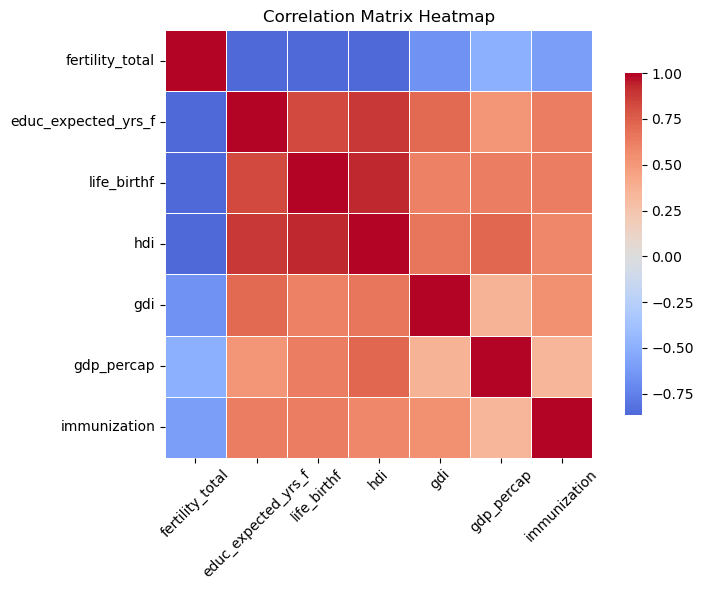

In [32]:
plt.figure(figsize=(8, 6))  # set size

sns.heatmap(corr_mx, 
            cmap="coolwarm",      # similar blue-orange color scheme
            center=0,             # center color scale at 0
            square=True,          # make cells square
            linewidths=0.5,       # grid lines between cells
            cbar_kws={"shrink": 0.8})  # color bar size adjustment

plt.title('Correlation Matrix Heatmap')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Principal Components Analysis

A key preliminary step to data modeling is dimensionality reduction: analyze the dataset to assess its correlation structure and extract insights to inform further analysis. 

Principal component analysis (PCA) reduces dimensionality by selecting components that capture the most variance and excluding those with weaker effects. This allows us to simplify the model by focusing on the most important features.

Each principal component (PC) is a linear combination (LC) of the form: 

$$
\text{PC} = \mathbf{Xv} = v_1 \mathbf{x}_1 + v_2 \mathbf{x}_2 + \cdots + v_p \mathbf{x}_p
$$

where 
- **$\mathbf{X}$** is the data matrix.
- **$\mathbf{v}$** is the vector of **loadings**  (weights or coefficients of the LC).

In this section, we apply PCA to identify components that capture the most variance in our data, providing insight into its underlying structure to guide further analysis and modeling.

#### Compute Principal Components

In `statsmodels`, the module `multivariate.pca` contains an easy implementation for computing principal components. 

Many relevant quantities can be retrieved as attributes, such as `loadings` (weights), `scores` (values of each LC), and `eigenvalues` of the correlation matrix.

In [33]:
# compute principal components
pca = PCA(data, standardize = True)

#### Variance Ratios

Variance ratios quantify the proportion of total variation captured by each PC. These are computed from the eigenvalues of the correlation matrix, with components ranked in order of descending variance. 

In [34]:
var_ratios = pca.eigenvals/pca.eigenvals.sum() # compute variance ratios

var_ratios  # display

0    0.721384
1    0.108046
2    0.069401
3    0.055937
4    0.021705
5    0.017333
6    0.006194
Name: eigenvals, dtype: float64

The first PC captures 72% of total variation, indicating a strong dominant pattern where a specific LC of factors likely explain fertility rates. The variables with the highest loadings on this component are key drivers of variability. 

This insight guides our next steps: identifying *which* factors are most influential in driving this primary component. 

#### Inspect Loadings

Now that we've identified the primary PC (PC1), we turn to inspect its loadings. 

Loadings are weights with which each variable contributes to a PC. A higher absolute value means the variable strongly influences the PC, while the sign reflects the direction of the relationship. 

In [35]:
# store variance ratios in a dataframe
pca_var_explained = pd.DataFrame({
    'Component': np.arange(1, len(var_ratios)+1),
    'Proportion of variance explained': var_ratios})

# extract first PC 
first_pc = pca.loadings.iloc[:, 0].values   # extract loadings
var_explained = var_ratios[0]    # proportion of variance captured by PC1

# display results 
print('number selected: ', 1)
print('proportion of variance captured: ', var_explained)

number selected:  1
proportion of variance captured:  0.7213844434872564


In [36]:
#  subset loadings
loading_df = pca.loadings.iloc[:, [0]]   # select loadings for PC1

# rename columns
loading_df = loading_df.rename(columns={'PC1': 'Loading'})

loading_df.head()   # print results 

,comp_0
fertility_total,-0.407364
educ_expected_yrs_f,0.412409
life_birthf,0.416766
hdi,0.425914
gdi,0.340855


These findings indicate that PC1 is primarily driven by positive loadings from education, life expectancy, HDI, and GDI. These are key drivers of variability in our dataset. 

The negative loading on fertility suggests an inverse relationship, where higher development and education correspond with lower fertility rates. PC1, therefore, captures a "developmental" axis where more developed countries tend to have lower fertility rates.

It's important to note that PCA captures variability in the entire dataset, not within individual variables. Thus, variables that were *not* included in the primary PCs shouldn't be immediately excluded.

In the next sections, we will use data visualization to further explore individual effects before modeling.

### Feature Analysis

Now that we've identified the primary drivers of total variability, it's crucial to further explore individual feature effects on total fertility rates. 

To this end, we will create scatterplots for each feature against fertility rates. This will allow us to visually inspect relationships, helping us gain deeper insight into the key drivers of total fertility.

#### Education 

The plot shows a negative association between fertility rate and education as expected. The relationship is roughly linear, indicating that higher educational levels tends to correspond with lower fertility rates.

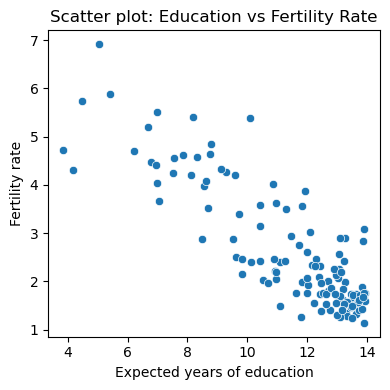

In [37]:
plt.figure(figsize=(4,4))  

sns.scatterplot(
    data=data,
    x="educ_expected_yrs_f",
    y="fertility_total"
)

plt.xlabel("Expected years of education")
plt.ylabel("Fertility rate")
plt.title("Scatter plot: Education vs Fertility Rate")

plt.tight_layout()
plt.show()

#### Life Expectancy 

There is a similar negative, approximately linear association between fertility rate and women's life expectancy. This aligns with our observations from correlation analysis and PCA.

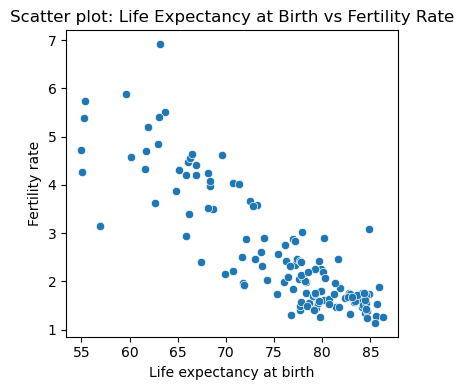

In [38]:
plt.figure(figsize=(4,4)) 

sns.scatterplot(
    data=data,
    x="life_birthf",
    y="fertility_total"
)

plt.xlabel("Life expectancy at birth")
plt.ylabel("Fertility rate")
plt.title("Scatter plot: Life Expectancy at Birth vs Fertility Rate")

plt.tight_layout()
plt.show()

#### HDI 

The plot shows that HDI is associated with lower fertility, though the relationship is more complex than a simple linear trend. Still, a linear approximation provides a reasonable summary.

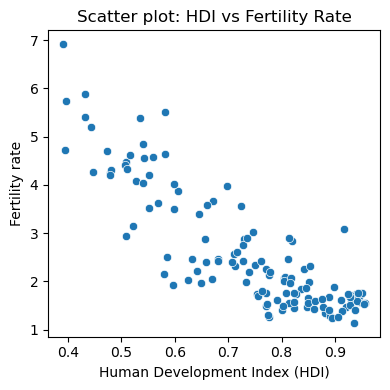

In [39]:
plt.figure(figsize=(4,4))
sns.scatterplot(data=data, x="hdi", y="fertility_total")
plt.xlabel("Human Development Index (HDI)")
plt.ylabel("Fertility rate")
plt.title("Scatter plot: HDI vs Fertility Rate")
plt.tight_layout()
plt.show()

#### GDI 

The plot reveals a clear negative, non-linear association between the GDI and total fertility. This suggests that as gender development improves, fertility tends to decline, but the relationship isn’t simply linear. 

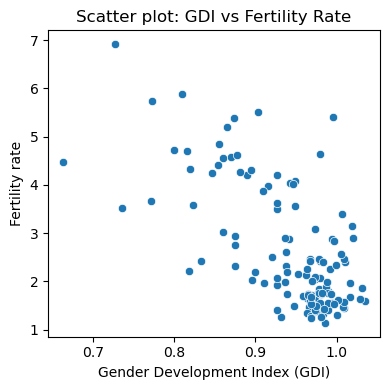

In [40]:
plt.figure(figsize=(4,4))
sns.scatterplot(data=data, x="gdi", y="fertility_total")
plt.xlabel("Gender Development Index (GDI)")
plt.ylabel("Fertility rate")
plt.title("Scatter plot: GDI vs Fertility Rate")
plt.tight_layout()
plt.show()

#### GDP Per Capita 

Here, the pattern resembles a multiplicative inverse, or possibly a logarithmic relationship: fertility rates tends to fall as GDP per capita increases, approaching a lower limit of 1. 

The rate of decrease is steepest in the [0, 40,000] range and slows after, suggesting that fertility rates drop  rapidly at lower income levels but stabilize as GDP reaches higher thresholds.

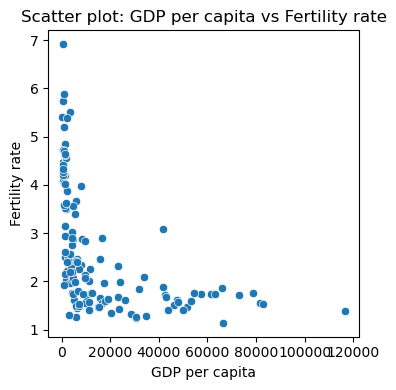

In [41]:
plt.figure(figsize=(4,4))
sns.scatterplot(data=data, x="gdp_percap", y="fertility_total")
plt.xlabel("GDP per capita")
plt.ylabel("Fertility rate")
plt.title("Scatter plot: GDP per capita vs Fertility rate")
plt.tight_layout()
plt.show()

#### Immunization Rate

Once again, we observe a negative relationship,  though the data are more scattered compared to other variables. Immunization rates mostly cluster between 90-100%, with fertility rates generally declining as immunization coverage increases.

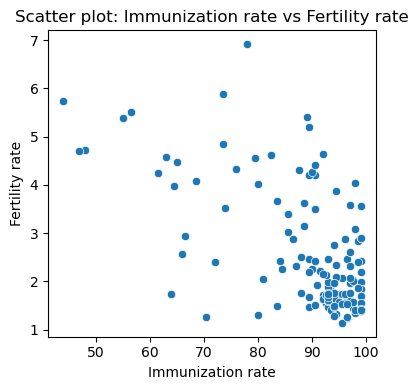

In [42]:
plt.figure(figsize=(4,4))
sns.scatterplot(data=data, x="immunization", y="fertility_total")
plt.xlabel("Immunization rate")
plt.ylabel("Fertility rate")
plt.title("Scatter plot: Immunization rate vs Fertility rate")
plt.tight_layout()
plt.show()


These visualization validate the insights derived from our previous analyses, confirming a strong linear negative relationship between fertility rates and education, life expectancy, HDI, and GDI. Meanwhile, GDP per capita and immunization rates show a more moderate, non-linear negative association.

## Multiple Regression Analysis

Now that we have a clearer understanding of how the variables influence fertility rates, we can proceed to modeling. 

First, we will define our model, fit it to the data, then evaluate its performance on multiple evaluation metrics. Then, we perform diagnostic tests to verify key assumptions before addressing the research questions.

Note that our goal is to *explain* fertility rates, not predict them. Thus, our analysis will focus on interpreting relationships instead of optimizing predictive accuracy. 

### Model Building

First, we will standardize the predictors. This will simplify comparison of effect sizes and help us understand how each feature influences fertility rates relative to overall variability. 

The response will be kept in its original units to facilitate interpretability of the results. 

In [43]:
# create response vector
y = data.fertility_total

# create design matrix 
mat = data.iloc[:,1:7]
mat = (mat-mat.mean())/mat.std()   # normalize features 

# add intercept column (constant 1's)  
x = sm.tools.add_constant(mat)

# print first five rows of x
x.head()

,const,educ_expected_yrs_f,life_birthf,hdi,gdi,gdp_percap,immunization
Country,,,,,,,
Afghanistan,1.0,-1.863465,-1.174374,-1.440808,-4.090610,-0.724618,-1.974439
Albania,1.0,0.727045,0.596805,0.370722,0.428830,-0.509795,0.656528
Algeria,1.0,0.285146,0.317620,0.076268,-1.199929,-0.560496,-0.262223
Angola,1.0,-1.791412,-1.469967,-0.973523,-0.568968,-0.599243,-2.684383
Argentina,1.0,0.670228,0.558729,0.690780,0.736974,-0.225086,0.113630


### Model Fitting 

Now, we fit the model to our data and evaluate its performance on error metrics, including R-squared, F-statistic, and p-value. These metrics provide insight into the model’s accuracy, generalizability, and overall fit. 

In [44]:
# fit model
mlr = sm.OLS(endog = y, exog = x)

# store result
rslt = mlr.fit()

# extract and print metrics 
print(f"R-squared: {rslt.rsquared:.3f}")
print(f"Adjusted R-squared: {rslt.rsquared_adj:.3f}")
print(f"F-statistic: {rslt.fvalue:.2f}")
print(f"F-statistic p-value: {rslt.f_pvalue:.4f}")

R-squared: 0.825
Adjusted R-squared: 0.816
F-statistic: 95.69
F-statistic p-value: 0.0000


Key metrics are summarized below:

* R-squared: 0.825, indicating the model explains 82.5% of the variation in fertility rates. 
* Adjusted R-squared: 0.816, close to R-squared, suggests no overfitting.
* F-statistic: 95.69 (p < 0.0001) confirms the model's statistical significance.

From these metrics, the model appears to be a strong fit. Before making any conclusions, we will perform diagnostic tests to verify key regression assumptions before proceeding with our analysis. 

### Model Diagnostics

In this section, we will verify key regression assumptions of normality, linearity, and constant error variance (homoscedasticity) using various statistical analysis and visualization techniques. 

These include: 

*  QQ plot: Validate normality assumptions for valid statistical inference. 

* Residual plots: Assess linearity and homoscedasticity (constant error variance).

* VIF: Flag multicollinearity (highly correlated features). 


#### Normality Check

In linear regression, residuals should follow a normal distribution to ensure valid statistical inference.

The QQ plot shows an approximately linear pattern with a slightly flatter line than the expected diagonal, indicating heavier tails and the presence of extreme values. The slight curvature also suggests mild skewness, though most points still align with the reference line.

These deviations are not severe, so the normality assumption holds reasonably valid for our model.

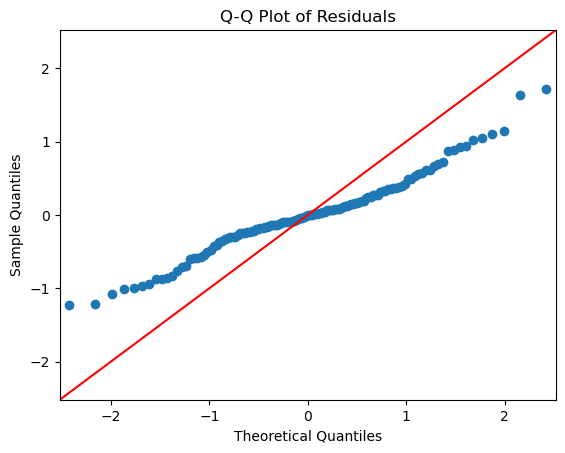

In [45]:
import statsmodels.api as sm
import matplotlib.pyplot as plt 

sm.qqplot(rslt.resid, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

#### Residual Plot

The residual plot shows random scatter with no apparent pattern, indicating homoscedasticity. A slight clustering around a fitted value of 1 may require further investigation but does not indicate a severe violation of assumptions.

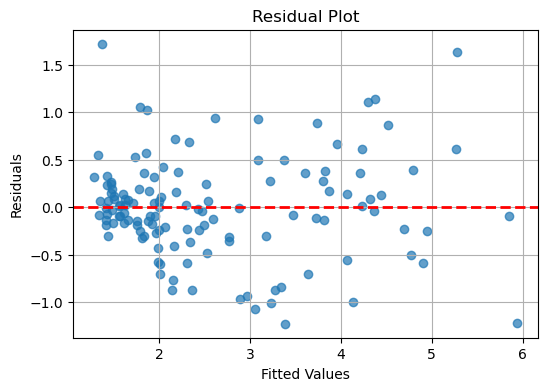

In [46]:
# create dataframe 
df = pd.DataFrame({
    'fitted_values': rslt.fittedvalues,  # Get fitted values
    'residuals': rslt.resid  # Get residuals
})

# create residual plot 
plt.figure(figsize=(6, 4))
plt.scatter(df['fitted_values'], df['residuals'], alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot')
plt.xlabel('Fitted Values'); plt.ylabel('Residuals')

plt.grid(True); plt.show()

#### Variance Inflation Factor (VIF)

Multicollinearity among features can lead to unstable coefficient estimates and hinder model interpretability. This may be an issue in our dataset, as indicated by our PCA analysis.

The Variance Inflation Factor (VIF) is used to quantify multicollinearity, with a common threshold of 10. High VIF values can inflate the significance of predictors, distorting the true effects of the features.

In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# compute the VIF for each feature in the design matrix x
vif_data = pd.DataFrame()
vif_data['Feature'] = x.columns
vif_data['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

# display the VIF values
print(vif_data)

               Feature        VIF
0                const   1.000000
1  educ_expected_yrs_f   6.084975
2          life_birthf   8.242011
3                  hdi  15.629728
4                  gdi   2.111264
5           gdp_percap   2.398091
6         immunization   1.863205


We find that `hdi`, `life_birthf`, and `educ_expected_yrs_f` have high VIF scores ranging from 6 to 15, while other variables have moderate to low VIFs. 


##### How should we proceed?

First, let's summarize our findings:

* HDI, education, and life expectancy are highly correlated (0.83-0.93), suggesting that these variables may be capturing similar underlying information.

* These features have high VIF scores that suggest problematic multicollinearity. 

A logical next step would be to remove `hdi` from our model. 

Recall that HDI is a composite measure of health, education, and standard of living, overlapping with other indicators such as education and life expectancy. Removing it will reduce multicollinearity while preserving most information, resulting in a simpler and clearer model.

In the next section, we will refine the model by removing `hdi`, recheck VIF for independence, and make further adjustments as needed.  

### Model Refinement

First, we will remove `hdi` and recheck VIF to confirm that multicollinearity is resolved. Then, we will build a new OLS model using the remaining predictors, evaluate its performance, and address our research questions based on the results.

In [48]:
# create new design matrix with hdi removed  
dm = data.iloc[:, 1:7]
dm = dm.drop(columns=['hdi'])   # drop hdi 

# normalize features 
dm = (dm - dm.mean()) / dm.std()

# add intercept column (constant 1's)
X = sm.tools.add_constant(dm)

print(X.columns)   # validate hdi has been removed 

Index(['const', 'educ_expected_yrs_f', 'life_birthf', 'gdi', 'gdp_percap',
       'immunization'],
      dtype='object')


In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# recheck VIF 
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# display the VIF values
print(vif_data)

               Feature       VIF
0                const  1.000000
1  educ_expected_yrs_f  4.133657
2          life_birthf  4.113814
3                  gdi  2.087899
4           gdp_percap  1.658830
5         immunization  1.808400


It seems like the issue has been resolved! With VIF values all around 1-4, our features no longer exhibit multicollinearity. We are good to proceed onto the next step: building a new OLS model!

Again, the predictors will be standardized with the response in its original units. 

In [50]:
# fit the OLS model
model = sm.OLS(endog=y, exog=X)   # using original response variable y

# store the result
results = model.fit()

# print evaluation metrics
print(f"R-squared: {results.rsquared:.3f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.3f}")
print(f"F-statistic: {results.fvalue:.2f}")
print(f"F-statistic p-value: {results.f_pvalue:.4f}")

R-squared: 0.822
Adjusted R-squared: 0.814
F-statistic: 113.28
F-statistic p-value: 0.0000


Let's analyze these metrics: 

* The R-squared value of 0.822 is very close to our old model (0.825), indicating that removing `hdi` had minimal impact on predictive power.
* A strong adjusted R-squared (0.814) indicates no overfitting. 
* The F-statistic increased to 113.28 (vs. 95.69), suggesting  an overall stronger fit.

Overall, removing `hdi` improved the model by reducing complexity while preserving accuracy. 

Next, we turn to address our research questions based on the OLS results.

## Research Questions 

In this section, we will analyze the OLS summary and tackle our research questions. 

* Which factors best predict a country’s fertility rate?
* How do upward mobility, economic prosperity, and child well-being impact fertility rates?
* Which of these explanations are the most probable?

#### Model Results

Recall that the predictors were standardized, while the response variable (fertility) was not. This means the coefficients represent the expected change in fertility rate (in original units) for a 1 standard deviation increase in each predictor.

The intercept reflects the expected fertility rate when all predictors are at their baseline (mean) values, expressed in the original units of fertility.

Keeping those notes in mind, let's analyze the OLS summary. 

In [51]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:        fertility_total   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     113.3
Date:                Sat, 24 May 2025   Prob (F-statistic):           2.57e-44
Time:                        02:40:12   Log-Likelihood:                -101.54
No. Observations:                 129   AIC:                             215.1
Df Residuals:                     123   BIC:                             232.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.6042    

A larger magnitude of coefficients suggests a stronger association with fertility rates, while larger t-values (and smaller p-values) indicate statistical significance.


Interpretation: 

* The intercept (const) of 2.6042 represents the expected fertility rate when all predictors are at their baseline, approximately 2.6 children per woman. 
* A 1 unit standard deviation increase in female education decreases fertility rates by 0.5132 units. 
* A 1 unit standard deviation increase in life expectancy decreases fertility rates by 0.6648 units.  
* GDI, GDP per capita, and immunization show weakly associations with fertility rates and are not statistically significant (p > 0.05). 

Key findings: 

* The strongest predictors are education and life expectancy, both are statistically significant (p < 0.05). They are negatively correlated with fertility, which supports the child well-being argument 
* Other predictors, such as GDI, GDP per capita, and immunization exhibit weak relationships and lack predictive power. 


Now, we turn to address our research questions.

#### Which factors best predict a country’s fertility rate? 

The most significant predictors of a country’s fertility rate are female education and life expectancy, both negatively associated with fertility. This suggests that higher female education is linked to lower fertility, likely due to delayed childbearing, career pursuits, and improved access to family planning.

Longer life expectancy also aligns with lower fertility, supporting the child well-being argument, where parents in healthier countries invest more resources in fewer children. 

#### How do upward mobility, economic prosperity, and child well-being impact fertility rates?


Upward mobility (proxied by education) relates to lower fertility through delayed childbearing.

Economic prosperity (GDP, GDI) shows weak associations, suggesting that factors like income distribution or social safety nets may be more influential than GDP alone.

Child well-being (proxied by life expectancy) negatively correlates with fertility, supporting the idea that better health outcomes lead to lower fertility as families focus on quality over quantity.

#### Which explanations are most probable?


Education and life expectancy stand out as the most likely explanations for fertility variation. Education reflects upward mobility linked to delayed childbearing, while life expectancy represents child well-being. 

GDP per capita has minimal impact, though GDI’s moderate role suggests gender development also influences fertility decisions.

## Conclusion

This project examined the decline in fertility rates across select countries using data from 2018. Due to the relatively small dataset and presence of unrelated features, we first tidied the data and performed exploratory analysis to uncover patterns. Variation in the data was assessed through correlation analysis and principal component analysis (PCA), followed by the development, refinement, and evaluation of a multiple regression model.

Our analysis revealed that both improvements in well-being and increased social mobility for women are negatively associated with fertility rates.

Limitations include dataset size, noise sensitivity, and time constraints. Additionally, focusing solely on 2018 data restricted the scope of our analysis. Future work could include additional variables, address missing data, and apply more robust models, such as time-series, to better capture temporal variations.